# Inspect a packaged change-detection NWB file

Walks through every table the pipeline produces, with plots inline so you can see what each table represents.

Structure:
1. **Task parameters** and **HED metadata** (session-level metadata)
2. **Epochs** — session segmentation (axvspan plot of the whole session)
3. **Intervals** — the canonical flat table of every interval (zoomed plot)
4. **Events** — discrete point events + meanings tables (overlay plot + lick analyses)
5. **Derived tables** — `trials`, `stimulus_presentations`, `natural_movie_one_presentations` (compositional views that combine timing from intervals/events with task annotations)
6. **Round-trip check** — confirm packaging is reversible

Switch `SESSION_DIR` and `NWB_NAME` in the loader cell below to inspect a different session.

**On `to_df()`:** NWB's schema stores the row-id at the path `id` inside every DynamicTable, so the index name can't be customized in storage. Our `to_df()` helper renames the dataframe index to `trials_id`, `stimulus_presentations_id`, etc. on read — clearer when joining tables.

In [23]:
# Install required packages if missing. Safe to re-run; pip is a no-op when already installed.
# %pip install --quiet pynwb ndx-events ndx-hed

In [24]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, Markdown, display


In [25]:
from pynwb import NWBHDF5IO
from ndx_events import EventsTable, NdxEventsNWBFile  # noqa: F401 — monkey-patches __getitem__

sys.path.insert(0, str(Path('data_loading_and_formatting_code').resolve()))
import ndx_change_detection_task  # noqa: F401 — registers namespace

In [26]:
SESSION_DIR = Path('new_ophys_mfish_data')
NWB_NAME = 'packaged_1464696201.nwb'
# alternative: 
# SESSION_DIR = Path('old_vbo_data')
# NWB_NAME = 'packaged_1050485649.nwb'

NWB_PATH = SESSION_DIR / NWB_NAME
io = NWBHDF5IO(str(NWB_PATH), 'r', load_namespaces=True)
nwb = io.read()
print(f'Loaded: {NWB_PATH}')
print(f'Session: {nwb.session_description}')
print(f'Start time: {nwb.session_start_time}')
print(f'Subject: {nwb.subject.subject_id} ({nwb.subject.species})')

Loaded: new_ophys_mfish_data/packaged_1464696201.nwb
Session: OPHYS_4_images_B
Start time: 2025-09-23 09:44:16.774000+00:00
Subject: 804670 (Mus musculus)


## NWB file structure

In [27]:
nwb

Data type,float64
Shape,"(270257,)"
Array size,2.06 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),2162056
Compressed size (bytes),2162056
Compression ratio,1.0
Data type,float64
Shape,"(270257,)"


## Task parameters

In [28]:
tp = nwb.lab_meta_data['task_parameters']
fields = sorted([f for f in tp.fields if not f.startswith('_')])
pd.DataFrame([(f, getattr(tp, f, None)) for f in fields],
             columns=['parameter', 'value'])

,parameter,value
0,auto_reward_delay_sec,0.15
1,auto_reward_volume_ml,0.005
2,blank_duration_sec,0.5
3,catch_mode,implicit
4,change_flashes_max,12
5,change_flashes_min,4
6,change_time_distribution,geometric
7,change_time_scale,0.3
8,end_after_response_sec,3.5
9,epilogue_frame_length_sec,0.033333


## HED metadata

In [29]:
print('HED schema version:', nwb.lab_meta_data['hed_schema'].hed_schema_version)

HED schema version: 8.3.0


In [30]:
def to_df(table, index_name: str | None = None) -> pd.DataFrame:
    """Convert an NWB DynamicTable to a DataFrame with a typed index name."""
    df = table.to_dataframe()
    df.index.name = index_name or f'{table.name}_id'
    return df

## Epochs

Session segmentation. Epochs live as rows of the flat `intervals` table with `interval_type=='epoch'`. Canonical names: `change_detection`, `natural_movie_one`, and `spontaneous` (fills any gap before/between/after the named epochs).

In [31]:
intervals_all = to_df(nwb.intervals['intervals'])
epochs = intervals_all[intervals_all['interval_type'] == 'epoch']
epochs[['start_time', 'stop_time', 'label', 'HED']]

,start_time,stop_time,label,HED
intervals_id,,,,
0,0.000000,317.048440,spontaneous,"Time-block, Pause, Label/spontaneous"
1,317.048440,3924.609850,change_detection,"Time-block, Experiment-procedure, Label/change..."
6110,3924.609850,4224.877994,spontaneous,"Time-block, Pause, Label/spontaneous"
6111,4224.877994,4525.127107,natural_movie_one,"Time-block, Sensory-event, Visual-presentation..."


**Plot:** all epochs across the full session.

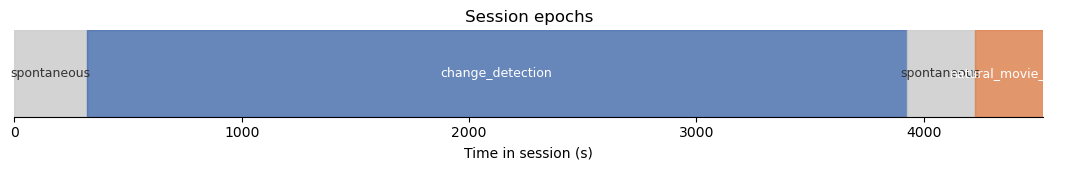

In [32]:
EPOCH_COLORS = {
    'change_detection': '#4C72B0',
    'natural_movie_one': '#DD8452',
    'spontaneous': '#cccccc',
}
fig, ax = plt.subplots(figsize=(11, 1.8))
for _, ep in epochs.iterrows():
    ax.axvspan(ep['start_time'], ep['stop_time'],
               color=EPOCH_COLORS.get(ep['label'], '#888888'),
               alpha=0.85)
    mid = (ep['start_time'] + ep['stop_time']) / 2
    ax.text(mid, 0.5, ep['label'], ha='center', va='center', fontsize=9,
            color='white' if ep['label'] != 'spontaneous' else '#333333')
ax.set_xlim(0, float(epochs['stop_time'].max()))
ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_xlabel('Time in session (s)')
ax.set_title('Session epochs')
for s in ('top', 'right', 'left'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## Intervals (canonical flat table)

Every session interval — epochs, trials, change/response windows, stimulus presentations, movie frames — lives in one timing-only table: `start_time`, `stop_time`, `interval_type`, `label`, foreign keys (`trials_id`, `stimulus_presentations_id`, `natural_movie_one_presentations_id`), and `HED`. Task-specific annotations (go/catch/hit/miss/image_name/etc.) are *not* here — they live on the per-type derived tables shown later.

In [33]:
intervals = to_df(nwb.intervals['intervals'])
print(f'{len(intervals)} intervals, {len(intervals.columns)} columns')
print('\nInterval types:')
print(intervals['interval_type'].value_counts().to_string())
print('\nSample HED strings by type:')
for itype in intervals['interval_type'].unique():
    sample = intervals.loc[intervals['interval_type'] == itype, 'HED'].iloc[0]
    print(f'  {itype:25s} {sample}')
intervals.head()

15112 intervals, 8 columns

Interval types:
interval_type
movie_frame              9000
stimulus_presentation    4806
trial                     547
change_window             417
response_window           338
epoch                       4

Sample HED strings by type:
  epoch                     Time-block, Pause, Label/spontaneous
  trial                     Experimental-trial, Incorrect-action, Label/aborted_trial
  stimulus_presentation     Sensory-event, Visual-presentation, (Image, Label/im000)
  change_window             Time-interval, (Task-property, Label/change_window)
  response_window           Time-interval, (Task-property, Label/response_window)
  movie_frame               Sensory-event, Visual-presentation, (Movie, Label/natural_movie_one)


,start_time,stop_time,interval_type,label,trials_id,stimulus_presentations_id,natural_movie_one_presentations_id,HED
intervals_id,,,,,,,,
0,0.000000,317.048440,epoch,spontaneous,-1,-1,-1,"Time-block, Pause, Label/spontaneous"
1,317.048440,3924.609850,epoch,change_detection,-1,-1,-1,"Time-block, Experiment-procedure, Label/change..."
2,317.048440,318.249430,trial,,0,-1,-1,"Experimental-trial, Incorrect-action, Label/ab..."
3,317.067404,317.317614,stimulus_presentation,im000,-1,0,-1,"Sensory-event, Visual-presentation, (Image, La..."
4,317.818024,318.068234,stimulus_presentation,im000,-1,1,-1,"Sensory-event, Visual-presentation, (Image, La..."


**Plot:** 1-minute zoom showing each interval type as a colored row.

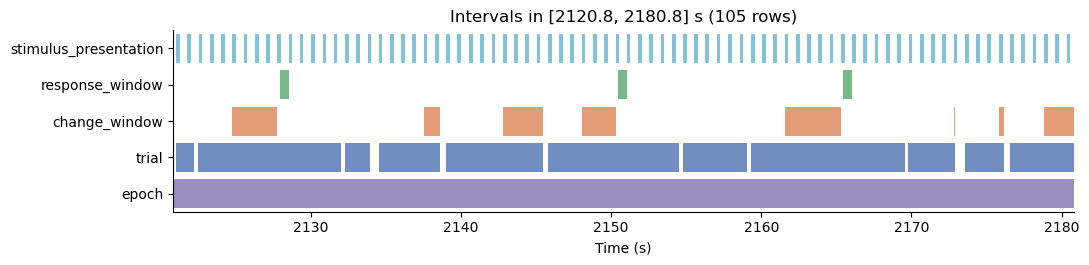

In [34]:
# Pick a 60-second window in the middle of change_detection
cd_ep = epochs[epochs['label'] == 'change_detection'].iloc[0]
t0 = (cd_ep['start_time'] + cd_ep['stop_time']) / 2
t1 = t0 + 60

# Stack interval types on separate rows for clarity
ITYPE_ORDER = ['epoch', 'trial', 'change_window', 'response_window',
               'stimulus_presentation', 'movie_frame']
ITYPE_COLORS = {
    'epoch': '#8172B3', 'trial': '#4C72B0',
    'change_window': '#DD8452', 'response_window': '#55A868',
    'stimulus_presentation': '#64B5CD', 'movie_frame': '#CCB974',
}
present = [t for t in ITYPE_ORDER
           if ((intervals['interval_type'] == t)
               & (intervals['start_time'] < t1)
               & (intervals['stop_time'] > t0)).any()]
fig, ax = plt.subplots(figsize=(11, max(2, 0.55 * len(present))))
for row_idx, itype in enumerate(present):
    rows = intervals[(intervals['interval_type'] == itype)
                     & (intervals['start_time'] < t1)
                     & (intervals['stop_time'] > t0)]
    for _, r in rows.iterrows():
        ax.add_patch(plt.Rectangle(
            (r['start_time'], row_idx + 0.1),
            max(r['stop_time'] - r['start_time'], 0.01), 0.8,
            color=ITYPE_COLORS[itype], alpha=0.8, lw=0))
ax.set_xlim(t0, t1)
ax.set_ylim(0, len(present))
ax.set_yticks([i + 0.5 for i in range(len(present))])
ax.set_yticklabels(present)
ax.set_xlabel('Time (s)')
ax.set_title(f'Intervals in [{t0:.1f}, {t1:.1f}] s '
             f'({sum(((intervals["interval_type"] == t) & (intervals["start_time"] < t1) & (intervals["stop_time"] > t0)).sum() for t in present)} rows)')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## Events (ndx-events EventsTable)

Discrete point events only: `lick`, `reward`, `image_change`, `image_omission`. Visual onsets/offsets aren't here — they're intervals (`stimulus_presentation` / `movie_frame` in the intervals table). 

Categorical columns follow HED's PASS design — `event_type` gives the base action, while `lick_classification`, `reward_type`, and `lick_bouts` provide independent orthogonal dimensions. Each categorical column has its own MeaningsTable carrying the HED fragment that composes into the full tag string.

In [35]:
et = nwb.get_events_table('events')
events = to_df(et)
print(f'{len(events)} events, {len(events.columns)} columns')
print('\nEvent types:')
print(events['event_type'].value_counts().to_string())
print('\nLick classifications (lick events only):')
lick_mask = events['event_type'] == 'lick'
print(events.loc[lick_mask, 'lick_classification'].value_counts().to_string())
print('\nReward types (reward events only):')
reward_mask = events['event_type'] == 'reward'
print(events.loc[reward_mask, 'reward_type'].value_counts().to_string())
print('\nLick bouts (lick events only):')
print(events.loc[lick_mask, 'lick_bouts'].value_counts().to_string())
events.head(10)

2526 events, 10 columns

Event types:
event_type
lick              1913
image_change       295
image_omission     200
reward             118

Lick classifications (lick events only):
lick_classification
consumption    1175
abort           205
late            187
false_alarm     151
hit             117
spontaneous      72
early             6

Reward types (reward events only):
reward_type
earned         113
auto_reward      5

Lick bouts (lick events only):
lick_bouts
within_bout    1425
bout_start      488


,timestamp,event_type,lick_classification,reward_type,lick_bouts,trials_id,stimulus_presentations_id,image_name,frame,reward_volume
events_id,,,,,,,,,,
0,317.932500,lick,abort,n/a,bout_start,0,1,,18038,NaN
1,320.820514,image_omission,n/a,n/a,n/a,1,5,,18210,NaN
2,323.823004,image_change,n/a,n/a,n/a,1,9,im031,18390,NaN
3,323.970850,reward,n/a,auto_reward,n/a,1,9,,18400,0.005
4,325.355330,lick,consumption,n/a,bout_start,1,11,,18483,NaN
5,325.488770,lick,consumption,n/a,within_bout,1,11,,18491,NaN
6,325.605540,lick,consumption,n/a,within_bout,1,11,,18498,NaN
7,325.722340,lick,consumption,n/a,within_bout,1,11,,18505,NaN
8,325.989190,lick,consumption,n/a,within_bout,1,11,,18521,NaN


### Meanings tables (HED fragments per categorical level)

In [36]:
for name in et.meanings_tables:
    mt = et.meanings_tables[name]
    print(f'\n=== {name} ({len(mt)} entries) ===')
    display(to_df(mt))


=== event_type_meanings (4 entries) ===


,value,meaning,value_description
event_type_meanings_id,,,
0,lick,"Agent-action, (Animal-agent, Move-face), Parti...","Time of a lick contact on the lick spout, dete..."
1,reward,"Sensory-event, Gustatory-presentation, (Ingest...",Time of a water-reward delivery to the lick sp...
2,image_change,"Sensory-event, Visual-presentation, Target, La...",Time of a stimulus presentation where the iden...
3,image_omission,"Sensory-event, Unexpected, Label/omitted_flash",Time of a scheduled image flash that was withh...



=== lick_bouts_meanings (3 entries) ===


,value,meaning,value_description
lick_bouts_meanings_id,,,
0,bout_start,"(Temporal-marker, Label/bout_start)",First lick of a bout: the inter-lick interval ...
1,within_bout,,Lick that occurs within an ongoing bout (inter...
2,n/a,,Not a lick event; this column does not apply.



=== lick_classification_meanings (8 entries) ===


,value,meaning,value_description
lick_classification_meanings_id,,,
0,hit,"Correct-action, Label/hit",First lick within the response window after an...
1,false_alarm,"Incorrect-action, Label/false_alarm",Incorrect lick occurring during the window of ...
2,abort,"Incorrect-action, Label/abort",Incorrect lick occurring in the 4 flash period...
3,early,"Incorrect-action, Label/early",Unrewarded lick in the 150 ms window after the...
4,late,"Incorrect-action, Label/late",Lick after the response window has closed on a...
5,consumption,Label/consumption,Lick after a reward delivery on the same trial...
6,spontaneous,Label/spontaneous,"Lick outside of any task-defined window (e.g.,..."
7,n/a,,Not a lick event; this column does not apply.



=== reward_type_meanings (3 entries) ===


,value,meaning,value_description
reward_type_meanings_id,,,
0,earned,Label/earned,Reward delivered as a consequence of a correct...
1,auto_reward,Label/auto_reward,Reward delivered automatically by the task (e....
2,n/a,,Not a reward event; this column does not apply.


**Plot:** same 1-minute window as above, now with events overlaid on the intervals.

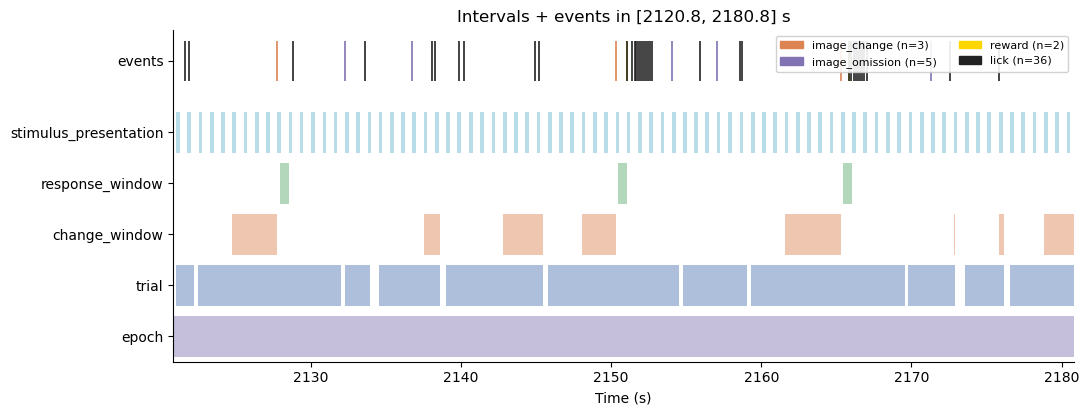

In [37]:
EVENT_COLORS = {
    'image_change': '#DD8452', 'image_omission': '#8172B3',
    'reward': '#FFD700', 'lick': '#222222',
}
fig, ax = plt.subplots(figsize=(11, max(2.5, 0.55 * len(present) + 1.5)))
# intervals (re-render so the figure stands alone)
for row_idx, itype in enumerate(present):
    rows = intervals[(intervals['interval_type'] == itype)
                     & (intervals['start_time'] < t1)
                     & (intervals['stop_time'] > t0)]
    for _, r in rows.iterrows():
        ax.add_patch(plt.Rectangle(
            (r['start_time'], row_idx + 0.1),
            max(r['stop_time'] - r['start_time'], 0.01), 0.8,
            color=ITYPE_COLORS[itype], alpha=0.45, lw=0))
# events as vertical ticks above the intervals
ev_row = len(present) + 0.5
window_ev = events[(events['timestamp'] >= t0) & (events['timestamp'] <= t1)]
handles = []
for etype, color in EVENT_COLORS.items():
    sub = window_ev[window_ev['event_type'] == etype]
    if len(sub):
        ax.vlines(sub['timestamp'], ev_row, ev_row + 0.8, color=color, lw=1.2)
        handles.append(mpatches.Patch(color=color, label=f'{etype} (n={len(sub)})'))
ax.set_xlim(t0, t1)
ax.set_ylim(0, len(present) + 1.5)
ax.set_yticks([i + 0.5 for i in range(len(present))] + [ev_row + 0.4])
ax.set_yticklabels(present + ['events'])
ax.set_xlabel('Time (s)')
ax.set_title(f'Intervals + events in [{t0:.1f}, {t1:.1f}] s')
ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** change- and omission-aligned lick distributions.

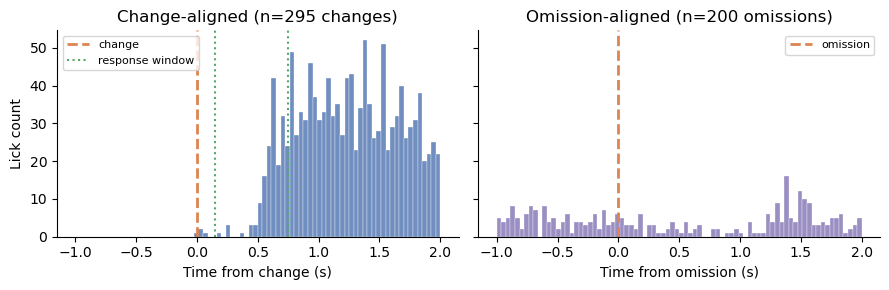

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
lick_events = events[events['event_type'] == 'lick']
change_events = events[events['event_type'] == 'image_change']
omit_events = events[events['event_type'] == 'image_omission']

# Change-aligned: latency from change to each lick in the same trial
change_lat = []
for _, ce in change_events.iterrows():
    trial_licks = lick_events[lick_events['trials_id'] == ce['trials_id']]
    lats = trial_licks['timestamp'].values - ce['timestamp']
    change_lat.extend(lats[(lats > -1) & (lats < 2)])
axes[0].hist(change_lat, bins=80, range=(-1, 2), color='#4C72B0', alpha=0.8,
             edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='#DD8452', ls='--', lw=2, label='change')
axes[0].axvline(0.15, color='#55A868', ls=':', lw=1.5, label='response window')
axes[0].axvline(0.75, color='#55A868', ls=':', lw=1.5)
axes[0].set_xlabel('Time from change (s)'); axes[0].set_ylabel('Lick count')
axes[0].set_title(f'Change-aligned (n={len(change_events)} changes)')
axes[0].legend(fontsize=8)

# Omission-aligned: latency from omission to nearby licks (no trial-id filtering needed —
# use temporal proximity to capture all licks within window)
omit_lat = []
omit_times = omit_events['timestamp'].values
lick_times = lick_events['timestamp'].values
for ot in omit_times:
    nearby = lick_times[(lick_times > ot - 1) & (lick_times < ot + 2)]
    omit_lat.extend(nearby - ot)
axes[1].hist(omit_lat, bins=80, range=(-1, 2), color='#8172B3', alpha=0.8,
             edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='#DD8452', ls='--', lw=2, label='omission')
axes[1].set_xlabel('Time from omission (s)')
axes[1].set_title(f'Omission-aligned (n={len(omit_events)} omissions)')
axes[1].legend(fontsize=8)
for ax in axes:
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** lick classification counts (orthogonal `lick_classification` column) and bout-start breakdown.

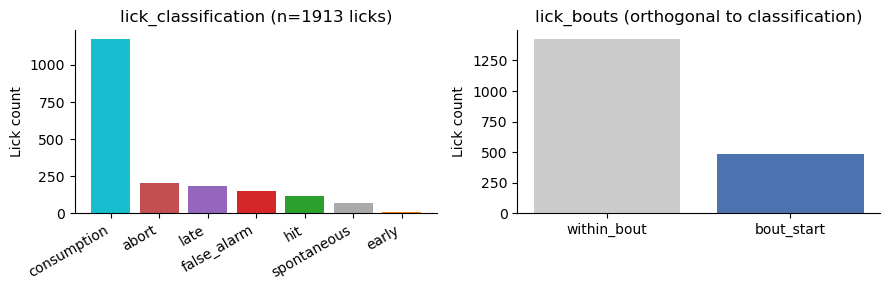

In [39]:
licks = events[events['event_type'] == 'lick'].copy()
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

# Lick classification counts
LICK_CLS_COLORS = {
    'hit': '#2ca02c', 'false_alarm': '#d62728', 'abort': '#C44E52',
    'early': '#ff7f0e', 'late': '#9467bd',
    'consumption': '#17becf', 'spontaneous': '#aaaaaa',
}
cls_counts = licks['lick_classification'].value_counts()
axes[0].bar(range(len(cls_counts)), cls_counts.values,
            color=[LICK_CLS_COLORS.get(c, '#888') for c in cls_counts.index])
axes[0].set_xticks(range(len(cls_counts)))
axes[0].set_xticklabels(cls_counts.index, rotation=30, ha='right')
axes[0].set_ylabel('Lick count')
axes[0].set_title(f'lick_classification (n={len(licks)} licks)')

# Lick bouts breakdown (orthogonal to classification)
bout = licks['lick_bouts'].value_counts()
axes[1].bar(range(len(bout)), bout.values, color=['#cccccc', '#4C72B0'])
axes[1].set_xticks(range(len(bout)))
axes[1].set_xticklabels(bout.index)
axes[1].set_ylabel('Lick count')
axes[1].set_title('lick_bouts (orthogonal to classification)')
for ax in axes:
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

---
## Running speed

Mouse running speed on the wheel, processed by the AllenSDK pipeline 
(rotary-encoder voltage → unwrap → angular change → linear speed via 
wheel geometry → 4 Hz Butterworth low-pass). Stored as a `TimeSeries` 
named `speed` in `nwb.processing['running']`, aligned to sync-file 
vsync falling edges (no monitor delay; running is a behavioral signal). 
Raw `dx`, `v_sig`, `v_in` are also stored for traceability.

In [40]:
running_mod = nwb.processing['running']
print('running interfaces:', list(running_mod.data_interfaces.keys()))
speed_ts = running_mod['speed']
speed = np.asarray(speed_ts.data[:])
speed_t = np.asarray(speed_ts.timestamps[:])
print(f'speed: {speed.shape}, unit={speed_ts.unit}, '
      f't=[{speed_t[0]:.2f}, {speed_t[-1]:.2f}] s')
print(f'min={np.nanmin(speed):.2f}  median={np.nanmedian(speed):.2f}  '
      f'mean={np.nanmean(speed):.2f}  max={np.nanmax(speed):.2f}  cm/s')

running interfaces: ['dx', 'speed']
speed: (270257,), unit=cm/s, t=[17.05, 4525.09] s
min=-21.77  median=26.82  mean=23.53  max=65.56  cm/s


**Plot:** full-session running speed, with epoch backgrounds. 
Confirms the trace spans the full session and that fingerprint / 
spontaneous gaps land in plausible places.

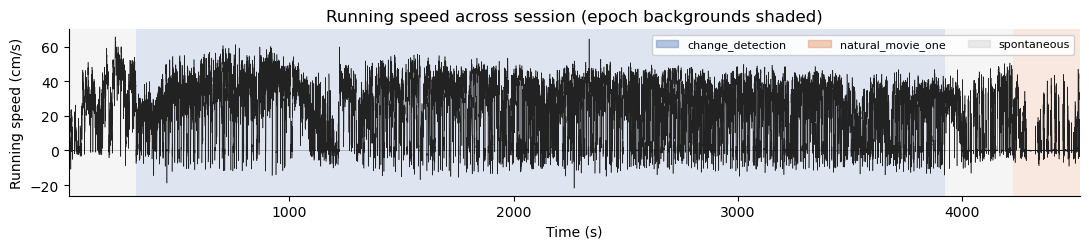

In [41]:
fig, ax = plt.subplots(figsize=(11, 2.6))
for _, ep in epochs.iterrows():
    ax.axvspan(ep['start_time'], ep['stop_time'],
               color=EPOCH_COLORS.get(ep['label'], '#cccccc'),
               alpha=0.18, lw=0)
ax.plot(speed_t, speed, color='#222222', lw=0.4)
ax.axhline(0, color='k', lw=0.4, alpha=0.4)
ax.set_xlim(speed_t[0], speed_t[-1])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Running speed (cm/s)')
ax.set_title('Running speed across session (epoch backgrounds shaded)')
handles = [mpatches.Patch(color=c, alpha=0.4, label=n)
           for n, c in EPOCH_COLORS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=3,
          framealpha=0.9)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** running speed overlaid on the same 1-minute window used 
above for intervals/events. Validates that the running-speed 
timestamps line up with stimulus presentations and behavioral events 
— e.g. running typically slows around hit changes (reward consumption) 
and accelerates between trials.

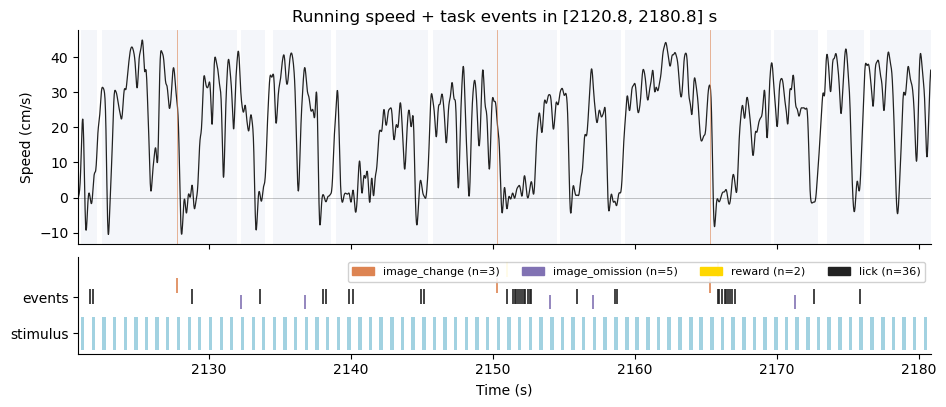

In [42]:
# Reuse t0/t1 from the intervals+events plots above.
mask = (speed_t >= t0) & (speed_t <= t1)
fig, (ax_s, ax_e) = plt.subplots(
    2, 1, figsize=(11, 4.2), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.0], 'hspace': 0.08})

# Top: running speed
ax_s.plot(speed_t[mask], speed[mask], color='#222222', lw=0.9)
ax_s.axhline(0, color='k', lw=0.4, alpha=0.4)
ax_s.set_ylabel('Speed (cm/s)')
ax_s.set_title(f'Running speed + task events in '
               f'[{t0:.1f}, {t1:.1f}] s')

# Bottom: stimulus_presentation rectangles + event ticks (same as cell
# 25, condensed onto one row each)
stim_rows = intervals[(intervals['interval_type'] == 'stimulus_presentation')
                      & (intervals['start_time'] < t1)
                      & (intervals['stop_time'] > t0)]
for _, r in stim_rows.iterrows():
    ax_e.add_patch(plt.Rectangle(
        (r['start_time'], 0.05),
        max(r['stop_time'] - r['start_time'], 0.01), 0.4,
        color=ITYPE_COLORS['stimulus_presentation'], alpha=0.6, lw=0))

# trial / change_window / response_window shading on the speed trace too
tr_rows = intervals[(intervals['interval_type'] == 'trial')
                    & (intervals['start_time'] < t1)
                    & (intervals['stop_time'] > t0)]
for _, r in tr_rows.iterrows():
    ax_s.axvspan(r['start_time'], r['stop_time'],
                 color=ITYPE_COLORS['trial'], alpha=0.06, lw=0)

# Events as vertical ticks on the bottom axis
ev_levels = {'image_change': 0.75, 'image_omission': 0.55,
             'reward': 0.95, 'lick': 0.62}
handles = []
window_ev = events[(events['timestamp'] >= t0)
                   & (events['timestamp'] <= t1)]
for etype, color in EVENT_COLORS.items():
    sub = window_ev[window_ev['event_type'] == etype]
    if len(sub):
        y = ev_levels[etype]
        ax_e.vlines(sub['timestamp'], y, y + 0.18, color=color, lw=1.2)
        handles.append(mpatches.Patch(color=color,
                                     label=f'{etype} (n={len(sub)})'))
        # Mark image_change times on the speed trace too
        if etype == 'image_change':
            for t in sub['timestamp']:
                ax_s.axvline(t, color=color, lw=0.6, alpha=0.7)

ax_e.set_xlim(t0, t1)
ax_e.set_ylim(0, 1.2)
ax_e.set_yticks([0.25, 0.7])
ax_e.set_yticklabels(['stimulus', 'events'])
ax_e.set_xlabel('Time (s)')
ax_e.legend(handles=handles, loc='upper right', fontsize=8, ncol=4,
            framealpha=0.9)
for s in ('top', 'right'):
    ax_s.spines[s].set_visible(False); ax_e.spines[s].set_visible(False)
plt.show()

---
## Behavior across trials

A per-trial view of the task, one trial per row, with time relative to each trial's start on the x-axis. This composes everything above into a single behavioral picture:

- **Background shading** marks the `change_window` (orange) and `response_window` (green) for that trial, pulled from the `trials` table.
- **Stimulus presentations** are drawn as a strip of rectangles along the top of each row (blue = regular flash, red = the change flash), from the `stimulus_presentations` table. Omitted flashes are left blank.
- **Running speed** is the black trace through the middle of each row (shared scale across the displayed trials).
- **Licks** are black ticks and **rewards** are gold markers along the bottom, from the `events` table.

The function below plots `n_trials` consecutive trials starting at `start_trial`.

In [53]:
# Derived tables used for the per-trial view (one row per trial / per flash).
trials = to_df(nwb.trials)
stim = to_df(nwb.intervals['stimulus_presentations'])

WINDOW_COLORS = {'change_window': '#DD8452', 'response_window': '#55A868'}
TRIAL_COLOR = '#999999'
STIM_COLOR = '#64B5CD'
CHANGE_COLOR = '#8172B3'
OUTCOMES = ['hit', 'miss', 'false_alarm', 'correct_reject', 'aborted', 'auto_rewarded']


def plot_behavior_across_trials(start_trial=1, n_trials=5, ax=None):
    """Plot behavior for `n_trials` consecutive trials, one trial per row.

    Each row is a single trial with time relative to its own start on the
    x-axis. The whole trial is shaded gray; change/response windows are
    colored overlays; stimulus presentations span the full row height
    (purple = change flash); running speed is the black trace; licks and
    rewards are marked along the bottom.
    """
    trial_ids = list(range(start_trial, start_trial + n_trials))
    sub = trials.loc[trial_ids]
    max_dur = float((sub['stop_time'] - sub['start_time']).max())

    # Shared running-speed scale across the displayed trials.
    m = (speed_t >= sub['start_time'].min()) & (speed_t <= sub['stop_time'].max())
    vmin, vmax = np.nanmin(speed[m]), np.nanmax(speed[m])
    vspan = max(vmax - vmin, 1e-6)

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, .5 * n_trials))
    else:
        fig = ax.figure

    band = 1.0                      # vertical height per trial
    run_lo, run_hi = 0.10, 0.78     # running-speed sub-band (fraction of band)
    lick_y = 0.03                   # lick / reward baseline

    for row, (tid, tr) in enumerate(sub.iterrows()):
        y0 = (n_trials - 1 - row) * band   # first trial at the top
        t0 = tr['start_time']

        # Whole trial shaded gray.
        ax.add_patch(plt.Rectangle((0, y0), tr['stop_time'] - t0, band,
                     color=TRIAL_COLOR, alpha=0.18, lw=0, zorder=0))

        # Change & response window overlays.
        for win, color in WINDOW_COLORS.items():
            ws, we = tr[f'{win}_start_time'], tr[f'{win}_stop_time']
            if np.isfinite(ws) and np.isfinite(we):
                ax.add_patch(plt.Rectangle((ws - t0, y0), we - ws, band,
                             color=color, alpha=0.30, lw=0, zorder=1))

        # Stimulus presentations span the full row height (skip omitted flashes).
        for _, s in stim[stim['trials_id'] == tid].iterrows():
            if bool(s['omitted']):
                continue
            is_change = bool(s['is_change'])
            ax.add_patch(plt.Rectangle((s['start_time'] - t0, y0),
                         max(s['stop_time'] - s['start_time'], 0.01), band,
                         color=CHANGE_COLOR if is_change else STIM_COLOR,
                         alpha=0.45 if is_change else 0.30, lw=0, zorder=2))

        # Running speed (normalized into the run sub-band).
        rm = (speed_t >= t0) & (speed_t <= tr['stop_time'])
        if rm.any():
            y = y0 + (run_lo + (speed[rm] - vmin) / vspan * (run_hi - run_lo)) * band
            ax.plot(speed_t[rm] - t0, y, color='#222222', lw=0.7, zorder=3)

        # Licks (black ticks) and rewards (gold markers).
        ev = events[(events['timestamp'] >= t0) & (events['timestamp'] <= tr['stop_time'])]
        licks = ev[ev['event_type'] == 'lick']
        ax.vlines(licks['timestamp'] - t0, y0 + lick_y, y0 + lick_y + 0.06 * band,
                  color='k', lw=0.8, zorder=4)
        rew = ev[ev['event_type'] == 'reward']
        ax.plot(rew['timestamp'] - t0, [y0 + lick_y + 0.03 * band] * len(rew),
                marker='v', ls='none', color='#FFD700', ms=7,
                markeredgecolor='k', markeredgewidth=0.4, zorder=5)

        # Row label: trial id + outcome.
        outcome = next((o for o in OUTCOMES if tr[o]), '')
        ax.text(-0.015 * max_dur, y0 + band / 2, f'trial {tid}\n{outcome}',
                ha='right', va='center', fontsize=8)

    ax.set_xlim(-0.12 * max_dur, max_dur * 1.02)
    ax.set_ylim(0, n_trials * band)
    ax.set_yticks([])
    ax.set_xlabel('Time from trial start (s)')
    ax.set_title(f'Behavior across trials {trial_ids[0]}–{trial_ids[-1]}')

    handles = [
        mpatches.Patch(color=TRIAL_COLOR, alpha=0.18, label='trial'),
        mpatches.Patch(color=WINDOW_COLORS['change_window'], alpha=0.30, label='change window'),
        mpatches.Patch(color=WINDOW_COLORS['response_window'], alpha=0.30, label='response window'),
        mpatches.Patch(color=STIM_COLOR, alpha=0.30, label='stimulus flash'),
        mpatches.Patch(color=CHANGE_COLOR, alpha=0.45, label='change flash'),
        plt.Line2D([], [], color='#222222', lw=0.9, label='running speed'),
        plt.Line2D([], [], color='k', lw=0.9, label='lick'),
        plt.Line2D([], [], marker='v', ls='none', color='#FFD700',
                   markeredgecolor='k', label='reward'),
    ]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
              fontsize=8, framealpha=0.9)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    return fig, ax


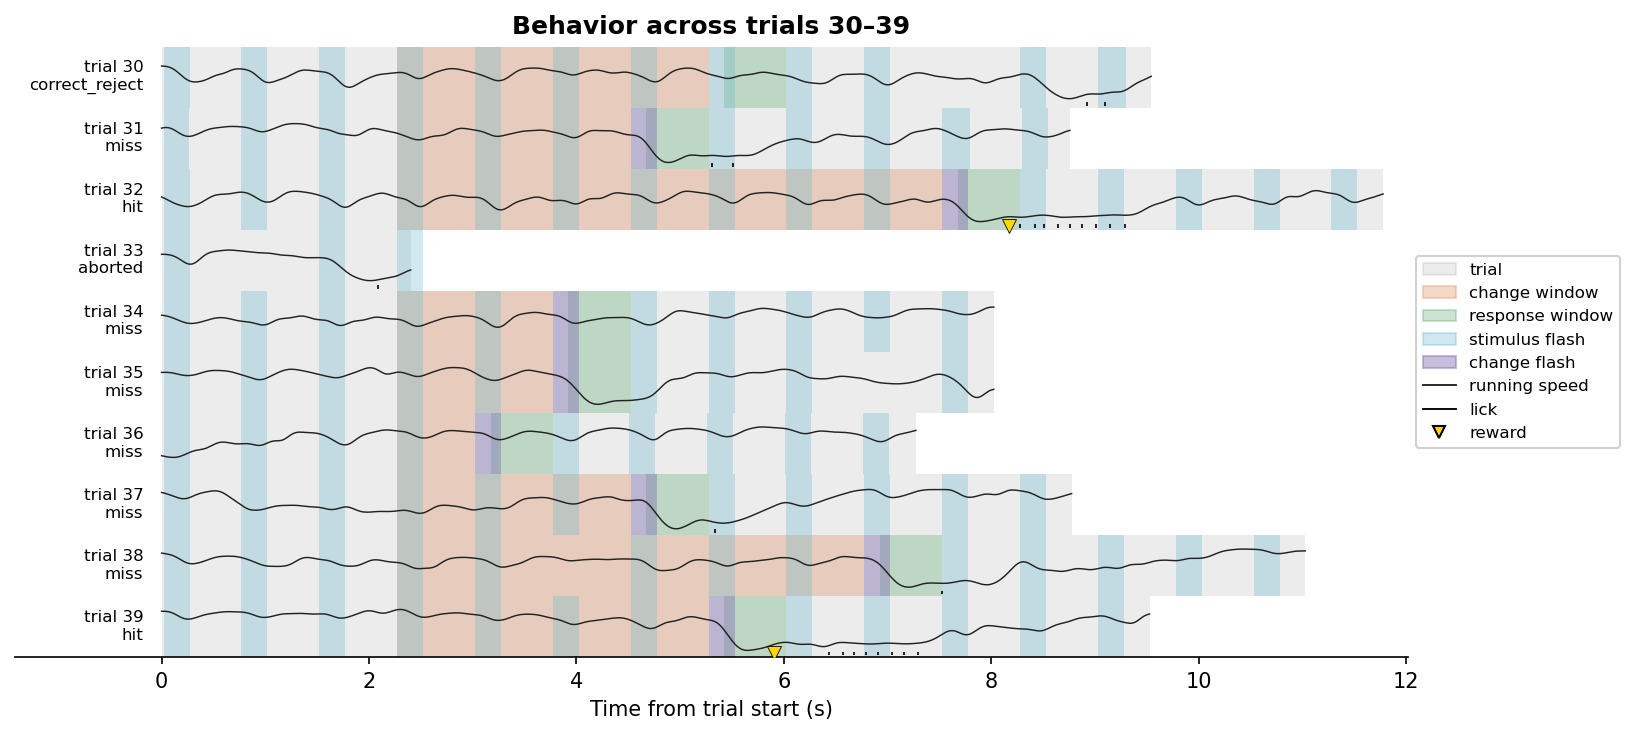

In [54]:
# Plot 5 consecutive trials. Change start_trial to look at a different stretch
# of the session (e.g. a run of go/hit trials, or aborted trials).
plot_behavior_across_trials(start_trial=30, n_trials=10)
plt.show()

A more compact, session-overview version: instead of one trial per row, lay out `trials_per_row` consecutive trials end-to-end along a single row, then wrap to the next row for the next block. Same encoding as above (gray trial, change/response windows, full-height flashes, running, licks, rewards), with white lines separating trials. This is closer to the "trials as ribbons" layout and makes session-scale structure (engagement, running, lick patterns) easy to scan.

In [55]:
def plot_trials_wrapped(start_trial=0, trials_per_row=10, n_rows=5, ax=None):
    """Plot trials as continuous ribbons, `trials_per_row` per row.

    Unlike `plot_behavior_across_trials` (one trial per row), this lays out
    `trials_per_row` consecutive trials end-to-end along a single row, then
    wraps to the next row for the following block — a compact session-overview
    ribbon. Each row's x-axis is time relative to that row's first trial.
    Shading/flashes/running/licks/rewards use the same encoding as the
    per-trial plot; white separators mark trial boundaries.
    """
    last = min(start_trial + trials_per_row * n_rows, len(trials))
    all_ids = list(range(start_trial, last))
    rows = [all_ids[i:i + trials_per_row] for i in range(0, len(all_ids), trials_per_row)]
    n_rows = len(rows)

    # Shared running-speed scale across everything displayed.
    sub = trials.loc[all_ids]
    m = (speed_t >= sub['start_time'].min()) & (speed_t <= sub['stop_time'].max())
    vmin, vmax = np.nanmin(speed[m]), np.nanmax(speed[m])
    vspan = max(vmax - vmin, 1e-6)

    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 1.1 * n_rows))
    else:
        fig = ax.figure

    band, gap = 1.0, 0.18
    run_lo, run_hi = 0.10, 0.80
    lick_y = 0.03

    def draw_trial(tid, t_origin, y0):
        tr = trials.loc[tid]
        t0 = tr['start_time']
        # Whole trial shaded gray + white separator at its start.
        ax.add_patch(plt.Rectangle((t0 - t_origin, y0), tr['stop_time'] - t0, band,
                     color=TRIAL_COLOR, alpha=0.18, lw=0, zorder=0))
        ax.plot([t0 - t_origin, t0 - t_origin], [y0, y0 + band],
                color='white', lw=0.6, zorder=2.5)
        # Change & response window overlays.
        for win, color in WINDOW_COLORS.items():
            ws, we = tr[f'{win}_start_time'], tr[f'{win}_stop_time']
            if np.isfinite(ws) and np.isfinite(we):
                ax.add_patch(plt.Rectangle((ws - t_origin, y0), we - ws, band,
                             color=color, alpha=0.30, lw=0, zorder=1))
        # Stimulus presentations span the full row height (skip omitted flashes).
        for _, s in stim[stim['trials_id'] == tid].iterrows():
            if bool(s['omitted']):
                continue
            is_change = bool(s['is_change'])
            ax.add_patch(plt.Rectangle((s['start_time'] - t_origin, y0),
                         max(s['stop_time'] - s['start_time'], 0.01), band,
                         color=CHANGE_COLOR if is_change else STIM_COLOR,
                         alpha=0.45 if is_change else 0.30, lw=0, zorder=2))
        # Running speed.
        rm = (speed_t >= t0) & (speed_t <= tr['stop_time'])
        if rm.any():
            y = y0 + (run_lo + (speed[rm] - vmin) / vspan * (run_hi - run_lo)) * band
            ax.plot(speed_t[rm] - t_origin, y, color='#222222', lw=0.6, zorder=3)
        # Licks and rewards.
        ev = events[(events['timestamp'] >= t0) & (events['timestamp'] <= tr['stop_time'])]
        licks = ev[ev['event_type'] == 'lick']
        ax.vlines(licks['timestamp'] - t_origin, y0 + lick_y, y0 + lick_y + 0.05 * band,
                  color='k', lw=0.6, zorder=4)
        rew = ev[ev['event_type'] == 'reward']
        ax.plot(rew['timestamp'] - t_origin, [y0 + lick_y + 0.025 * band] * len(rew),
                marker='v', ls='none', color='#FFD700', ms=5,
                markeredgecolor='k', markeredgewidth=0.3, zorder=5)

    max_span = 0.0
    for r, ids in enumerate(rows):
        y0 = (n_rows - 1 - r) * (band + gap)   # first block at the top
        t_origin = trials.loc[ids[0], 'start_time']
        max_span = max(max_span, trials.loc[ids[-1], 'stop_time'] - t_origin)
        for tid in ids:
            draw_trial(tid, t_origin, y0)
        ax.text(-0.01 * max_span, y0 + band / 2, f'trials\n{ids[0]}–{ids[-1]}',
                ha='right', va='center', fontsize=8)

    ax.set_xlim(-0.06 * max_span, max_span * 1.01)
    ax.set_ylim(-gap, n_rows * (band + gap))
    ax.set_yticks([])
    ax.set_xlabel('Time within row (s)')
    ax.set_title(f'Behavior across trials {all_ids[0]}–{all_ids[-1]} '
                 f'({trials_per_row} trials per row)')

    handles = [
        mpatches.Patch(color=TRIAL_COLOR, alpha=0.18, label='trial'),
        mpatches.Patch(color=WINDOW_COLORS['change_window'], alpha=0.30, label='change window'),
        mpatches.Patch(color=WINDOW_COLORS['response_window'], alpha=0.30, label='response window'),
        mpatches.Patch(color=STIM_COLOR, alpha=0.30, label='stimulus flash'),
        mpatches.Patch(color=CHANGE_COLOR, alpha=0.45, label='change flash'),
        plt.Line2D([], [], color='#222222', lw=0.9, label='running speed'),
        plt.Line2D([], [], color='k', lw=0.9, label='lick'),
        plt.Line2D([], [], marker='v', ls='none', color='#FFD700',
                   markeredgecolor='k', label='reward'),
    ]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
              fontsize=8, framealpha=0.9)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    return fig, ax


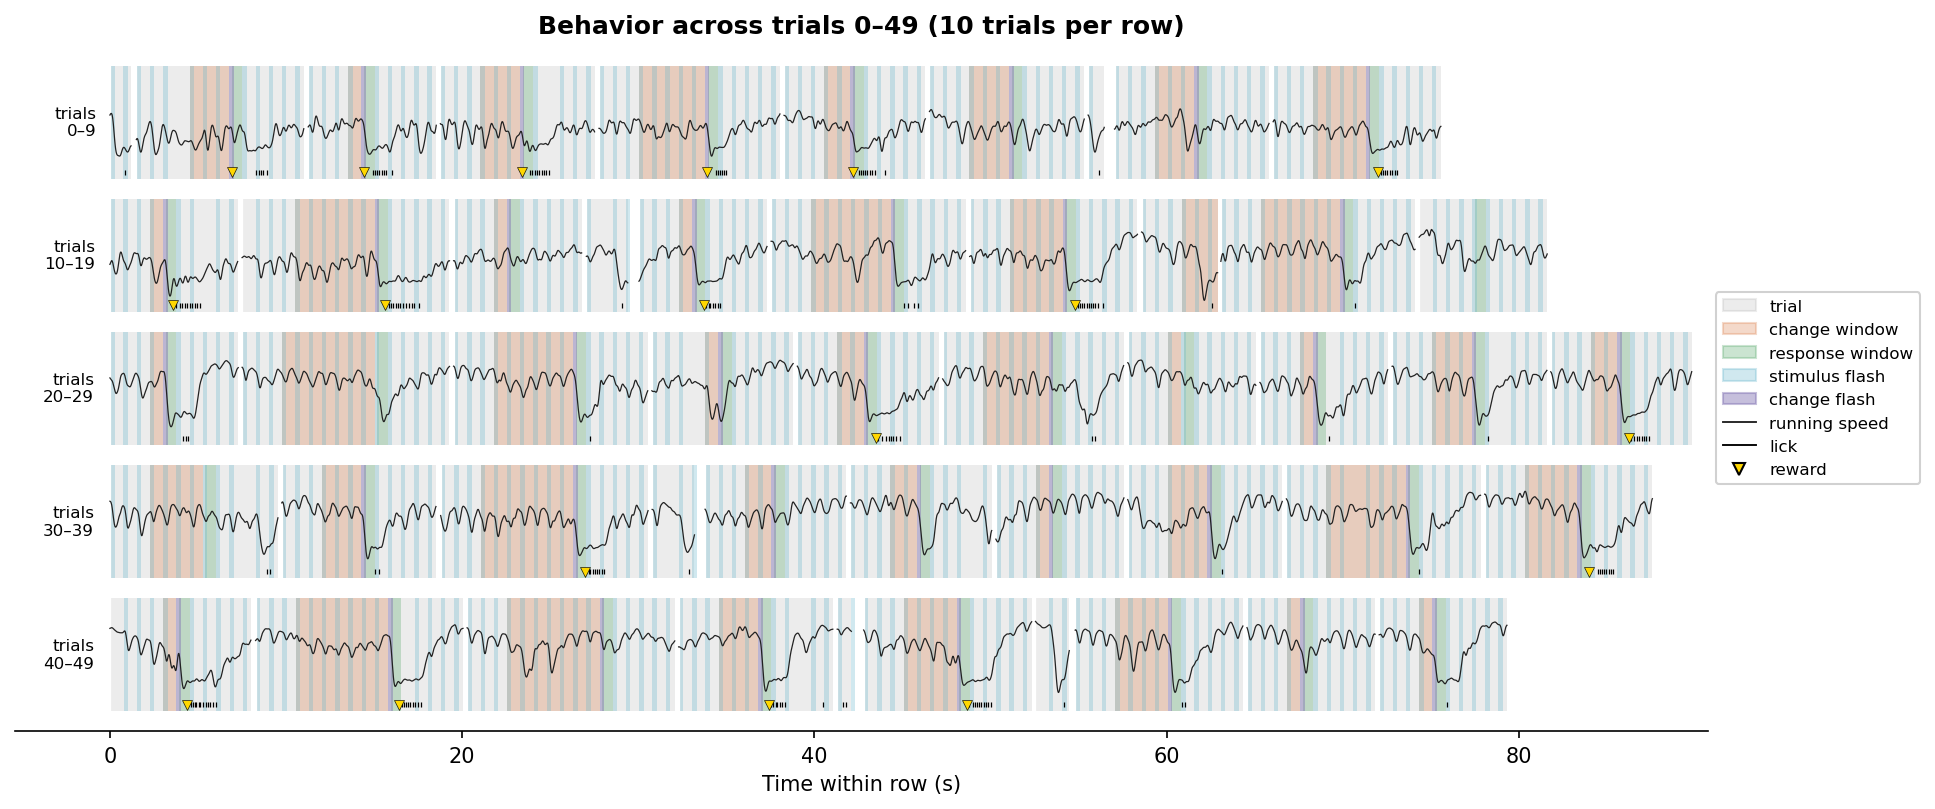

In [56]:
# 10 trials per row, 5 rows (trials 0-49). Bump start_trial / n_rows to scan
# further into the session.
plot_trials_wrapped(start_trial=0, trials_per_row=10, n_rows=5)
plt.show()

---
## Derived tables

The previous sections covered the **raw tables** — `intervals` (every timing fact) and `events` (every discrete event) with HED tags. Everything that happened in the session can be reconstructed from those two.

The tables below are **compositional views** built on top — they duplicate timing from `intervals` and add the task-specific annotations needed to *interpret* what each interval means:

- **`trials`** — one row per behavioral trial, with outcome flags (`go`, `catch`, `hit`, `miss`, `false_alarm`, `correct_reject`, `aborted`, `auto_rewarded`), the image identity before and after the change, reward/response times, and the change/response window timing for that trial.
- **`stimulus_presentations`** — one row per image flash, with `image_name`, `is_change`, and `omitted` flags.
- **`natural_movie_one_presentations`** — one row per movie frame, with `movie_frame_index` and `movie_repeat`.

You don't *need* these for low-level analyses (you can derive everything from the raw tables), but they're the natural starting point for trial- or stimulus-level analyses. The foreign-key columns on the `intervals` table (`trials_id`, `stimulus_presentations_id`, `natural_movie_one_presentations_id`) let you join back.

Importantly, these tables match the content and organization in the legacy AllenSDK tables, ensuring cross-compatibility across datasets and facilitating analyses using existing pipelines that rely on this structure 

### Trials

In [43]:
trials = to_df(nwb.trials)
print(f'{len(trials)} trials, {len(trials.columns)} columns')
trials.head()

547 trials, 25 columns


,start_time,stop_time,go,catch,auto_rewarded,aborted,hit,miss,false_alarm,correct_reject,...,reward_time,reward_volume,response_time,response_latency,change_window_start_time,change_window_stop_time,response_window_start_time,response_window_stop_time,epoch_name,HED
trials_id,,,,,,,,,,,,,,,,,,,,,
0,317.04844,318.24943,False,False,True,True,False,False,False,False,...,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,change_detection,"Experimental-trial, Incorrect-action, Label/ab..."
1,318.54968,328.05758,False,False,True,False,False,False,False,False,...,323.97085,0.005,325.35533,1.532326,321.571134,323.823004,323.973004,324.573004,change_detection,"Experimental-trial, Reward, Label/auto_rewarde..."
2,328.30779,335.58048,False,False,True,False,False,False,False,False,...,331.46041,0.005,331.97749,0.648246,330.578614,331.329244,331.479244,332.079244,change_detection,"Experimental-trial, Reward, Label/auto_rewarde..."
3,335.81401,344.57130,False,False,True,False,False,False,False,False,...,340.46787,0.005,340.91825,0.581536,338.084854,340.336714,340.486714,341.086714,change_detection,"Experimental-trial, Reward, Label/auto_rewarde..."
4,344.82149,355.09669,False,False,True,False,False,False,False,False,...,350.97663,0.005,351.44368,0.598206,347.092324,350.845474,350.995474,351.595474,change_detection,"Experimental-trial, Reward, Label/auto_rewarde..."


In [44]:
outcome_cols = ['hit', 'miss', 'false_alarm', 'correct_reject',
                'aborted', 'auto_rewarded', 'go', 'catch', 'warm_up']
print('Trial outcomes (counts):')
for c in outcome_cols:
    print(f'  {c:>15}: {int(trials[c].sum())}')

Trial outcomes (counts):
              hit: 113
             miss: 177
      false_alarm: 5
   correct_reject: 38
          aborted: 209
    auto_rewarded: 6
               go: 290
            catch: 70
          warm_up: 5


### Stimulus presentations

In [45]:
sp = to_df(nwb.intervals['stimulus_presentations'])
print(f'{len(sp)} rows ({(~sp["omitted"].astype(bool)).sum()} flashes, '
      f'{sp["omitted"].astype(bool).sum()} omitted, '
      f'{int(sp["is_change"].sum())} changes)')
sp.head()

4806 rows (4606 flashes, 200 omitted, 295 changes)


,start_time,stop_time,image_name,is_change,omitted,stimulus_presentations_id,trials_id,start_frame,stop_frame,lick_latency,epoch_name,HED
stimulus_presentations_id,,,,,,,,,,,,
0,317.067404,317.317614,im000,False,False,0,0,17985,18000,NaN,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
1,317.818024,318.068234,im000,False,False,1,0,18030,18045,0.114476,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
2,318.568644,318.818854,im000,False,False,2,1,18075,18090,NaN,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
3,319.319264,319.569514,im000,False,False,3,1,18120,18135,NaN,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
4,320.069894,320.320104,im000,False,False,4,1,18165,18180,NaN,change_detection,"Sensory-event, Visual-presentation, (Image, La..."


### Natural movie one presentations

In [46]:
if 'natural_movie_one_presentations' in nwb.intervals:
    movie = to_df(nwb.intervals['natural_movie_one_presentations'])
    print(f'{len(movie)} frames across {int(movie["movie_repeat"].max() + 1)} repeats')
    display(movie.head())
else:
    print('No natural_movie_one_presentations in this session.')

9000 frames across 10 repeats


,start_time,stop_time,movie_frame_index,movie_repeat,start_frame,stop_frame,epoch_name,HED
natural_movie_one_presentations_id,,,,,,,,
0,4224.877994,4224.911364,0,0,252257,252259,natural_movie_one,"Sensory-event, Visual-presentation, (Movie, La..."
1,4224.911364,4224.944724,1,0,252259,252261,natural_movie_one,"Sensory-event, Visual-presentation, (Movie, La..."
2,4224.944724,4224.978084,2,0,252261,252263,natural_movie_one,"Sensory-event, Visual-presentation, (Movie, La..."
3,4224.978084,4225.011444,3,0,252263,252265,natural_movie_one,"Sensory-event, Visual-presentation, (Movie, La..."
4,4225.011444,4225.044794,4,0,252265,252267,natural_movie_one,"Sensory-event, Visual-presentation, (Movie, La..."


---
## Round-trip check

Confirm that `nwb_to_dfs(nwb)` rebuilds the original CSV-format dataframes and that they match the intermediate CSVs byte-for-byte through the validation plots. If this passes, packaging is reversible — every fact you started with is in the NWB.

In [47]:
from package_to_nwb import nwb_to_dfs
import importlib, make_validation_plots
importlib.reload(make_validation_plots)
import make_validation_plots as mvp
import hashlib, io as _io

ev_nwb, iv_nwb = nwb_to_dfs(nwb)
ev_csv = pd.read_csv(SESSION_DIR / 'events_table_draft.csv')
iv_csv = pd.read_csv(SESSION_DIR / 'intervals_table_draft.csv')

# `miss` is no longer an event by design (it's a trial outcome on nwb.trials),
# so drop it from the CSV side before comparing.
ev_csv = ev_csv[ev_csv['event_type'] != 'miss'].reset_index(drop=True)

def plot_hash(ev, iv):
    fig = mvp.plot_events_detail(ev, iv)
    buf = _io.BytesIO(); fig.savefig(buf, format='png', dpi=80); plt.close(fig)
    return hashlib.md5(buf.getvalue()).hexdigest()

h_csv = plot_hash(ev_csv, iv_csv)
h_nwb = plot_hash(ev_nwb, iv_nwb)
print(f'CSV (no miss) \u2192 plot md5: {h_csv}')
print(f'NWB           \u2192 plot md5: {h_nwb}')
print('round-trip OK' if h_csv == h_nwb else 'MISMATCH \u2014 investigate')

CSV (no miss) → plot md5: 7d241b99dbfa586a1f057e3c467b0299
NWB           → plot md5: 7d241b99dbfa586a1f057e3c467b0299
round-trip OK
